In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pmdarima as pm
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Rinkinių sujungimas

In [17]:
sentinel_data = pd.read_csv("Sentinel_5p_data.csv")
sentinel_data.head()

,Unnamed: 0,time,absorbing_aerosol_index,cloud_fraction,cloud_top_pressure,cloud_top_height,cloud_base_pressure,cloud_base_height,cloud_optical_depth,NO2_column_number_density,tropospheric_NO2_column_number_density,stratospheric_NO2_column_number_density,NO2_slant_column_number_density,tropopause_pressure,O3_column_number_density,O3_effective_temperature,CO_column_number_density,H2O_column_number_density
0,0,2018-07-04 00:00:00+03:00,-0.621235,NaN,NaN,NaN,NaN,NaN,NaN,0.000077,NaN,0.000062,0.000203,19219.670,NaN,NaN,NaN,NaN
1,1,2018-07-05 00:00:00+03:00,-0.659180,NaN,NaN,NaN,NaN,NaN,NaN,0.000072,0.000011,0.000065,0.000146,19219.450,NaN,NaN,0.027964,1824.4277
2,2,2018-07-06 00:00:00+03:00,-1.010234,NaN,NaN,NaN,NaN,NaN,NaN,0.000079,0.000010,0.000067,0.000198,19218.373,NaN,NaN,0.029050,1257.0642
3,3,2018-07-07 00:00:00+03:00,-1.175477,NaN,NaN,NaN,NaN,NaN,NaN,0.000083,0.000017,0.000069,0.000194,19223.537,NaN,NaN,0.028928,1455.8580
4,4,2018-07-08 00:00:00+03:00,-1.260407,NaN,NaN,NaN,NaN,NaN,NaN,0.000077,0.000006,0.000073,0.000199,19230.297,NaN,NaN,0.028053,1655.6798


In [18]:
sentinel_data = sentinel_data.drop(columns=['Unnamed: 0'])

sentinel_data['time'] = pd.to_datetime(sentinel_data['time'], errors='coerce', utc=True)

sentinel_data['time'] = sentinel_data['time'].dt.tz_convert(None).dt.normalize()

sentinel_data = sentinel_data.set_index('time').sort_index()
sentinel_data.head(10)

,absorbing_aerosol_index,cloud_fraction,cloud_top_pressure,cloud_top_height,cloud_base_pressure,cloud_base_height,cloud_optical_depth,NO2_column_number_density,tropospheric_NO2_column_number_density,stratospheric_NO2_column_number_density,NO2_slant_column_number_density,tropopause_pressure,O3_column_number_density,O3_effective_temperature,CO_column_number_density,H2O_column_number_density
time,,,,,,,,,,,,,,,,
2018-06-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000088,0.000021,0.000066,0.000174,16689.959,NaN,NaN,NaN,NaN
2018-06-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000082,0.000012,0.000066,0.000199,16677.684,NaN,NaN,NaN,NaN
2018-06-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000078,0.000007,0.000063,0.000156,19222.316,NaN,NaN,NaN,NaN
2018-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000075,NaN,0.000063,0.000191,19223.482,NaN,NaN,NaN,NaN
2018-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000075,NaN,0.000062,0.000193,22057.926,NaN,NaN,NaN,NaN
2018-07-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000079,0.000009,0.000066,0.000196,22067.760,NaN,NaN,NaN,NaN
2018-07-03,-0.621235,NaN,NaN,NaN,NaN,NaN,NaN,0.000077,NaN,0.000062,0.000203,19219.670,NaN,NaN,NaN,NaN
2018-07-04,-0.659180,NaN,NaN,NaN,NaN,NaN,NaN,0.000072,0.000011,0.000065,0.000146,19219.450,NaN,NaN,0.027964,1824.4277
2018-07-05,-1.010234,NaN,NaN,NaN,NaN,NaN,NaN,0.000079,0.000010,0.000067,0.000198,19218.373,NaN,NaN,0.029050,1257.0642


In [19]:
meteo_data = pd.read_csv("Vilnius_meteo_data_new_2017_2026.csv")
meteo_data.head()

,observationTime,airTemperature,seaLevelPressure,relativeHumidity,missforest_precipitation,cloudCover_fixed,feelsLikeTemperature_fixed,windSpeed_fixed,windGust_fixed,windDirection_fixed
0,2017-11-01,4.145455,1008.427273,93.954545,7.0,96.181818,2.100000,2.800000,10.0,252.0
1,2017-11-02,8.333333,1000.604167,95.500000,11.7,94.000000,6.750000,2.766667,9.3,242.0
2,2017-11-03,7.320833,1009.004167,94.708333,2.1,96.000000,5.770833,2.520833,8.3,294.0
3,2017-11-04,6.191667,1017.487500,93.166667,0.0,94.500000,4.175000,2.775000,7.1,210.0
4,2017-11-05,6.229167,1015.329167,87.708333,0.0,72.708333,3.475000,3.825000,9.5,157.0


In [20]:
meteo_data['observationTime'] = pd.to_datetime(meteo_data['observationTime'])
meteo_data['observationTime'] = meteo_data['observationTime'].dt.normalize()
meteo_data = meteo_data.set_index('observationTime')

In [21]:
cams_data = pd.read_csv("CAMS_data.csv")
cams_data.head()

,Unnamed: 0,time,dust,sia,pm2p5,pans,nmvoc,nh3,pm10
0,0,2018-01-01 00:00:00+02:00,0.027574,3.349921,6.089184,0.407313,2.398289,0.016827,7.808134
1,1,2018-01-02 00:00:00+02:00,0.027978,3.154068,6.762302,0.671220,2.569455,0.063430,9.598956
2,2,2018-01-03 00:00:00+02:00,0.028735,3.811160,5.880989,0.701758,4.656805,0.011970,7.649660
3,3,2018-01-04 00:00:00+02:00,0.004460,4.234188,7.021877,0.677830,5.965854,0.008702,10.568492
4,4,2018-01-05 00:00:00+02:00,0.001764,3.885617,7.876541,0.630805,4.946000,0.023550,13.354506


In [22]:
cams_data = cams_data.drop(columns=['Unnamed: 0'])
cams_data['time'] = pd.to_datetime(cams_data['time'], errors='coerce', utc=True)
cams_data['time'] = cams_data['time'].dt.tz_localize(None).dt.normalize()

cams_data = cams_data.set_index('time')

In [54]:
metop_data = pd.read_csv("../ACSAF/METOP_B_data_Vilnius.csv")
metop_data.head()

,BrO,BrO_Error,H2O,H2O_Error,HCHO,HCHO_Error,NO2,NO2Tropo,NO2Tropo_Error,NO2_Error,O3,O3_Error,SO2,SO2_Error,lat,lon,km_to_Vilnius
0,4.067824e+13,1.023224e+13,NaN,NaN,NaN,NaN,1.264781e+15,NaN,NaN,1.597650e+14,302.81918,1.759856,1.136063,2.270313,54.684470,24.742430,34.535499
1,7.065945e+13,1.138130e+13,NaN,NaN,NaN,NaN,7.236719e+14,NaN,NaN,1.764434e+14,379.83438,1.755172,1.360049,2.843774,54.803345,25.401083,15.082633
2,4.116689e+13,1.681828e+13,4.462987,27.776356,NaN,NaN,9.663619e+14,NaN,NaN,2.304058e+14,383.20250,1.683177,0.860705,2.764343,54.627434,24.767618,33.602005
3,4.442434e+13,1.095781e+13,NaN,NaN,NaN,NaN,1.146257e+15,NaN,NaN,2.067150e+14,388.79135,2.050939,-6.458092,6.844355,54.632540,24.958952,21.506666
4,5.585372e+13,9.920312e+12,4.439587,28.882318,NaN,NaN,1.740549e+15,NaN,NaN,1.492338e+14,388.53107,2.883507,-0.614635,3.620795,54.742348,25.373165,8.581625


In [23]:
combined_data = meteo_data.join(sentinel_data, how='left')
combined_data = combined_data.join(cams_data, how='left')

# combined_data = combined_data.iloc[:-70]

combined_data.tail()

,airTemperature,seaLevelPressure,relativeHumidity,missforest_precipitation,cloudCover_fixed,feelsLikeTemperature_fixed,windSpeed_fixed,windGust_fixed,windDirection_fixed,absorbing_aerosol_index,...,O3_effective_temperature,CO_column_number_density,H2O_column_number_density,dust,sia,pm2p5,pans,nmvoc,nh3,pm10
observationTime,,,,,,,,,,,,,,,,,,,,,
2026-02-26,-2.091667,1029.875000,77.875000,0.0,74.625000,-5.054167,2.904167,8.5,164.0,-0.040404,...,218.77048,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-02-27,-0.079167,1023.645833,75.958333,0.0,73.125000,-4.491667,4.170833,9.4,169.0,0.048590,...,218.54755,0.028851,820.22450,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-02-28,3.412500,1021.220833,75.375000,0.0,15.208333,0.800000,2.758333,5.3,161.0,0.047702,...,219.84673,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-01,3.387500,1020.195833,81.916667,0.0,50.625000,0.379167,3.341667,12.6,160.0,-0.306471,...,220.63535,0.032981,490.22372,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-02,1.700000,1021.900000,80.000000,0.0,94.000000,-1.550000,3.100000,7.6,254.0,-0.156267,...,219.33050,0.034470,397.12286,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Bendro rinkinio apžvalga

In [24]:
def check_data_boundaries(df):
    boundaries = []
    
    for col in df.columns:
        first_idx = df[col].first_valid_index()
        last_idx = df[col].last_valid_index()
        
        count_not_na = df[col].count()
        
        boundaries.append({
            'Stulpelis': col,
            'Pirma ne NA': first_idx,
            'Paskutinė ne NA': last_idx,
            'Viso taškų': count_not_na
        })
    
    boundary_df = pd.DataFrame(boundaries)
    return boundary_df

In [25]:
info_table = check_data_boundaries(combined_data)
print(info_table.to_string(index=False))

                              Stulpelis Pirma ne NA Paskutinė ne NA  Viso taškų
                         airTemperature  2017-11-01      2026-03-02        3044
                       seaLevelPressure  2017-11-01      2026-03-02        3044
                       relativeHumidity  2017-11-01      2026-03-02        3044
               missforest_precipitation  2017-11-01      2026-03-02        3044
                       cloudCover_fixed  2017-11-01      2026-03-02        3044
             feelsLikeTemperature_fixed  2017-11-01      2026-03-02        3044
                        windSpeed_fixed  2017-11-01      2026-03-02        3044
                         windGust_fixed  2017-11-01      2026-03-02        3044
                    windDirection_fixed  2017-11-01      2026-03-02        3044
                absorbing_aerosol_index  2018-07-03      2026-03-02        2777
                         cloud_fraction  2018-07-11      2026-03-02        2603
                     cloud_top_pressure 

In [26]:
cut_combined_data = combined_data.loc['2018-07-01':'2026-01-31'].copy()

In [27]:
missing_percent = cut_combined_data.isnull().mean() * 100
print(missing_percent)

airTemperature                              0.000000
seaLevelPressure                            0.000000
relativeHumidity                            0.000000
missforest_precipitation                    0.000000
cloudCover_fixed                            0.000000
feelsLikeTemperature_fixed                  0.000000
windSpeed_fixed                             0.000000
windGust_fixed                              0.000000
windDirection_fixed                         0.000000
absorbing_aerosol_index                     0.901876
cloud_fraction                              7.178932
cloud_top_pressure                         10.966811
cloud_top_height                           11.002886
cloud_base_pressure                        10.966811
cloud_base_height                          11.002886
cloud_optical_depth                        11.002886
NO2_column_number_density                   6.457431
tropospheric_NO2_column_number_density     43.290043
stratospheric_NO2_column_number_density     6.

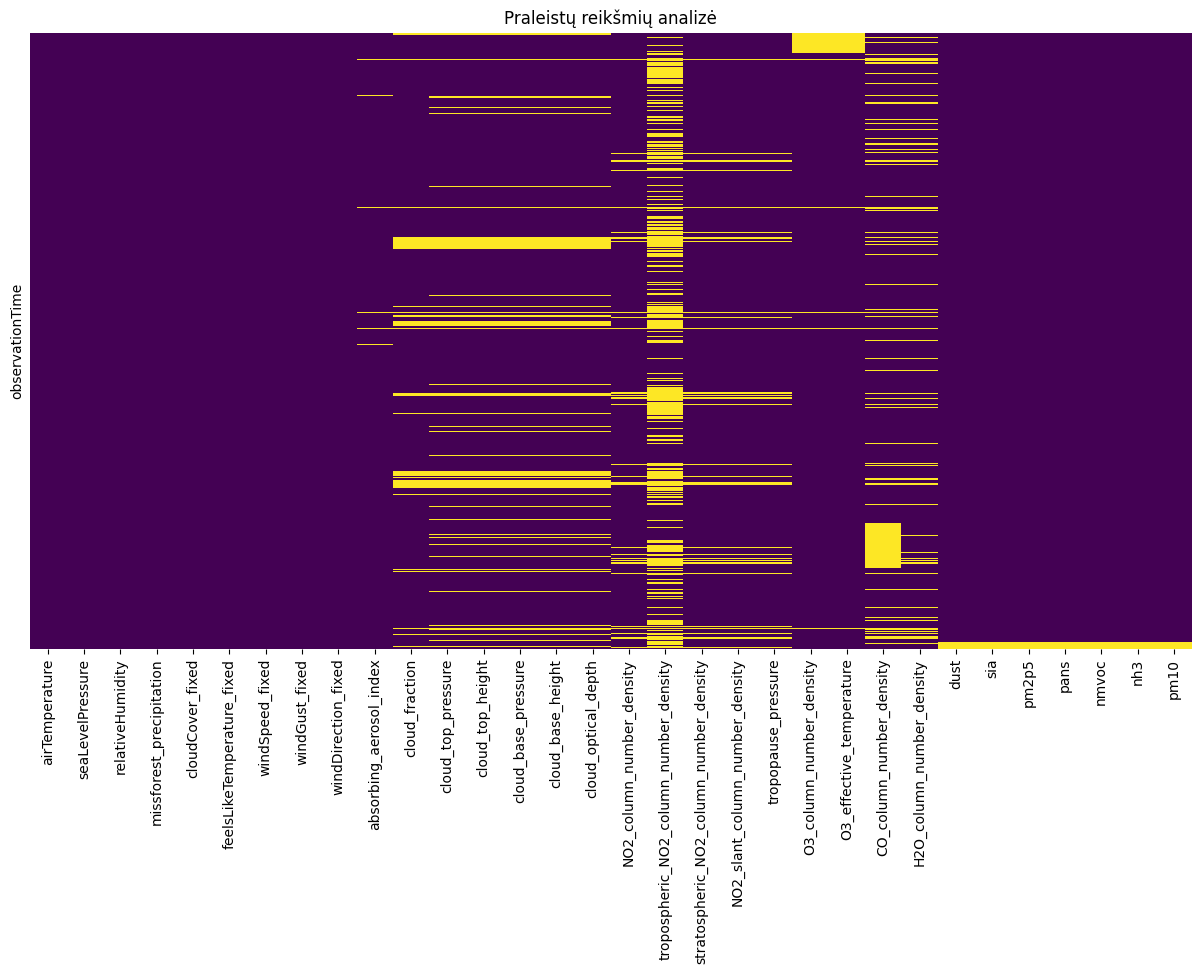

In [28]:
plt.figure(figsize=(15, 8))
sns.heatmap(cut_combined_data.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Praleistų reikšmių analizė')
plt.show()

In [29]:
max_gap = {}

for col in cut_combined_data.columns:
    first_idx = cut_combined_data[col].first_valid_index()
    
    if first_idx is not None:
        subset = cut_combined_data.loc[first_idx:, col]
        
        is_nan = subset.isnull()
        groups = (is_nan != is_nan.shift()).cumsum()
        gap_sizes = is_nan.groupby(groups).sum()
    
        max_gap[col] = gap_sizes.max()
    else:
        max_gap[col] = None

max_gap

{'airTemperature': np.int64(0),
 'seaLevelPressure': np.int64(0),
 'relativeHumidity': np.int64(0),
 'missforest_precipitation': np.int64(0),
 'cloudCover_fixed': np.int64(0),
 'feelsLikeTemperature_fixed': np.int64(0),
 'windSpeed_fixed': np.int64(0),
 'windGust_fixed': np.int64(0),
 'windDirection_fixed': np.int64(0),
 'absorbing_aerosol_index': np.int64(2),
 'cloud_fraction': np.int64(32),
 'cloud_top_pressure': np.int64(32),
 'cloud_top_height': np.int64(32),
 'cloud_base_pressure': np.int64(32),
 'cloud_base_height': np.int64(32),
 'cloud_optical_depth': np.int64(32),
 'NO2_column_number_density': np.int64(4),
 'tropospheric_NO2_column_number_density': np.int64(50),
 'stratospheric_NO2_column_number_density': np.int64(4),
 'NO2_slant_column_number_density': np.int64(4),
 'tropopause_pressure': np.int64(4),
 'O3_column_number_density': np.int64(5),
 'O3_effective_temperature': np.int64(5),
 'CO_column_number_density': np.int64(201),
 'H2O_column_number_density': np.int64(5),
 'dust

In [30]:
cut_combined_data = cut_combined_data.drop(columns=['tropospheric_NO2_column_number_density'])

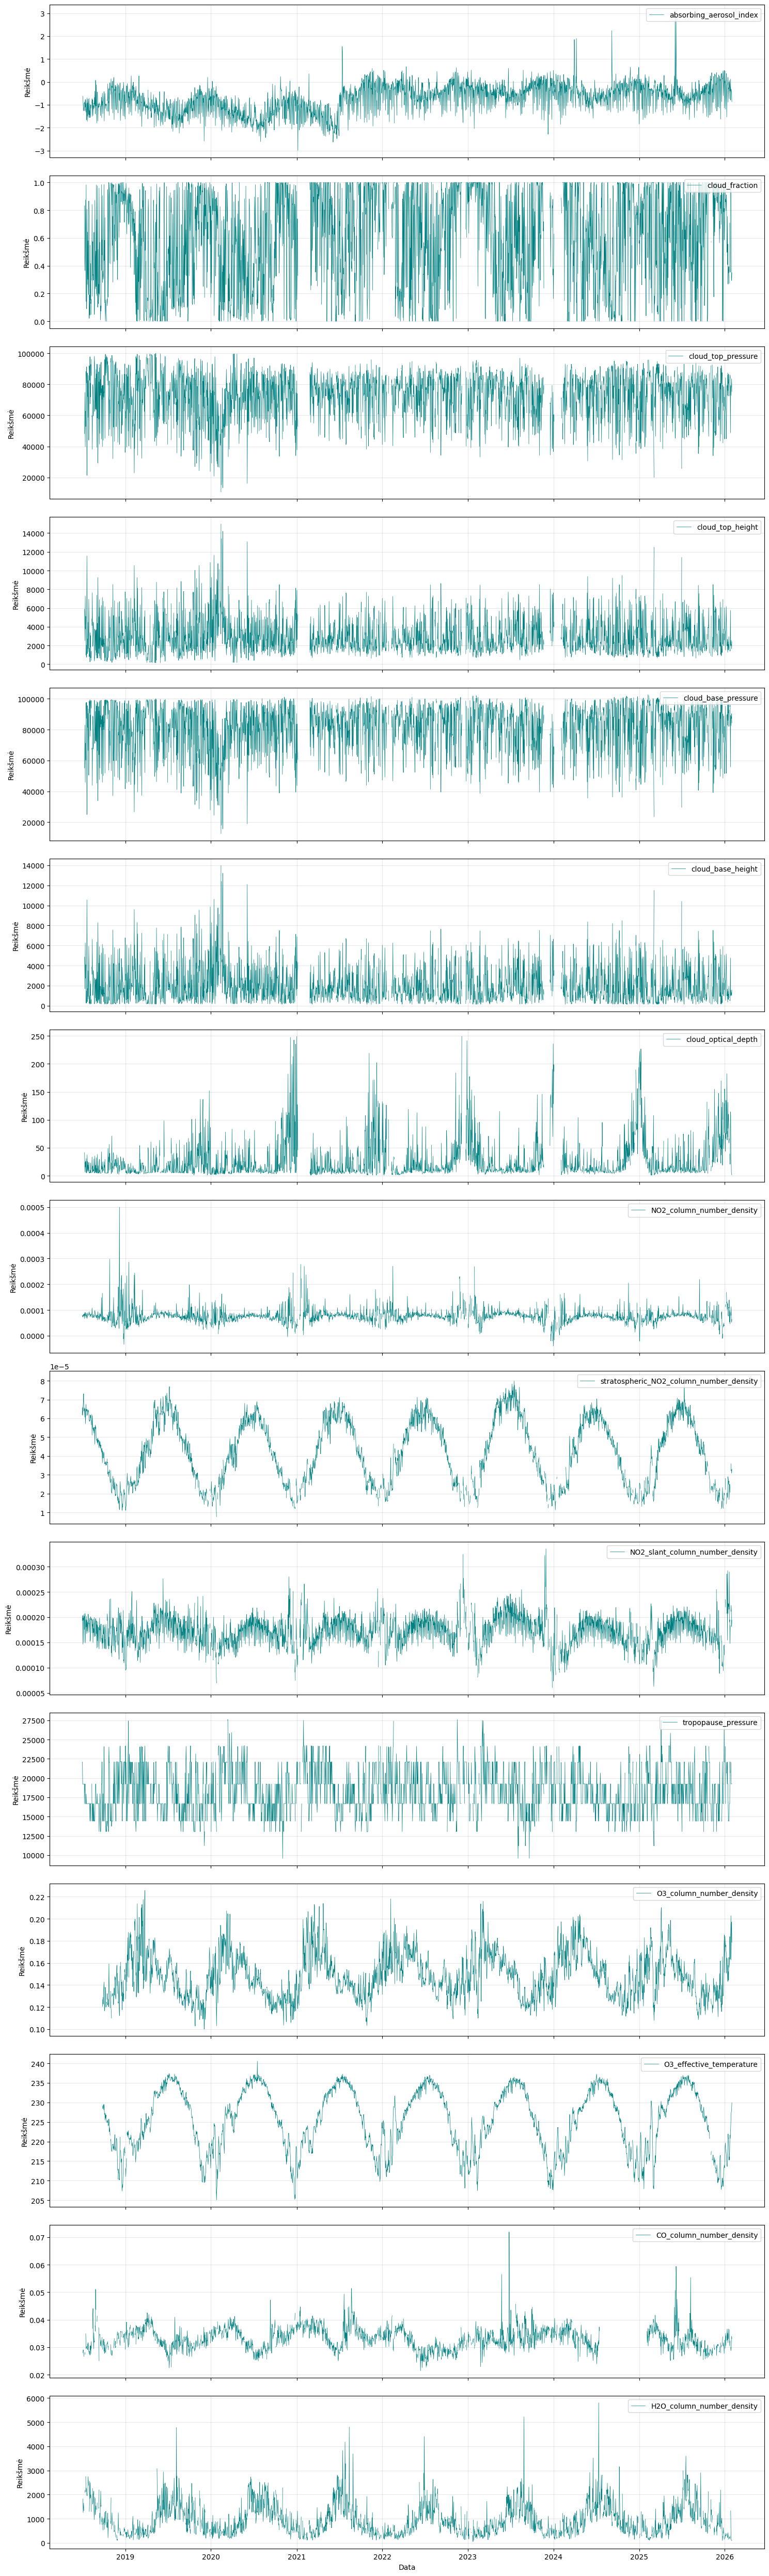

In [33]:
cols_to_show = ['absorbing_aerosol_index', 'cloud_fraction', 'cloud_top_pressure', 'cloud_top_height', 'cloud_base_pressure',
                'cloud_base_height', 'cloud_optical_depth',  'NO2_column_number_density',
                'stratospheric_NO2_column_number_density', 'NO2_slant_column_number_density', 'tropopause_pressure', 'O3_column_number_density',
                'O3_effective_temperature', 'CO_column_number_density', 'H2O_column_number_density']

fig, axes = plt.subplots(len(cols_to_show), 1, figsize=(15, 50), sharex=True)

for i, col in enumerate(cols_to_show):
    axes[i].plot(cut_combined_data.index, cut_combined_data[col], label=col, color='teal', linewidth=0.5)
    axes[i].set_ylabel('Reikšmė')
    axes[i].legend(loc='upper right')
    axes[i].grid(True, alpha=0.3)

plt.xlabel('Data')
plt.tight_layout()
plt.show()

In [ ]:
# corr_matrix = combined_data.corr()

# plt.figure(figsize=(12, 8))
# sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
# plt.show()

# Bazinis modelis

In [ ]:
def impute_with_sarima(df, target_col):
    series = df[target_col].copy()
    
    if not series.isna().any():
        return series

    nan_indices = series[series.isna()].index
    
    y_train = series.interpolate(method='linear').dropna()
    
    try:
        print(f"Apmokomas Auto-ARIMA stulpeliui: {target_col}...")
        model = pm.auto_arima(y_train, seasonal=True, m=7, stepwise=True, suppress_warnings=True)
        
        for idx in nan_indices:
            series.loc[idx] = model.predict(n_periods=1)[0]
            
    except Exception as e:
        print(f"Klaida pildant {target_col}: {e}. Naudojama tiesinė interpoliacija.")
        series = series.interpolate(method='linear').fillna(method='bfill').fillna(method='ffill')
        
    return series

In [ ]:
sarima_data = cut_combined_data.copy()

cols_to_fix = [col for col in sarima_data.columns if sarima_data[col].isna().any()]

for col in cols_to_fix:
    sarima_data[col] = impute_with_sarima(sarima_data, col)

print("Užpildymas baigtas!")

Apmokomas Auto-ARIMA stulpeliui: absorbing_aerosol_index...


C:\Users\rugil\AppData\Local\Temp\ipykernel_23364\2853130822.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  series.loc[idx] = model.predict(n_periods=1)[0]
C:\Users\rugil\AppData\Local\Temp\ipykernel_23364\2853130822.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  series.loc[idx] = model.predict(n_periods=1)[0]
C:\Users\rugil\AppData\Local\Temp\ipykernel_23364\2853130822.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


Apmokomas Auto-ARIMA stulpeliui: cloud_fraction...


C:\Users\rugil\AppData\Local\Temp\ipykernel_23364\2853130822.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  series.loc[idx] = model.predict(n_periods=1)[0]
C:\Users\rugil\AppData\Local\Temp\ipykernel_23364\2853130822.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  series.loc[idx] = model.predict(n_periods=1)[0]
C:\Users\rugil\AppData\Local\Temp\ipykernel_23364\2853130822.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


Apmokomas Auto-ARIMA stulpeliui: cloud_top_pressure...


...

C:\Users\rugil\AppData\Local\Temp\ipykernel_23364\2853130822.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  series.loc[idx] = model.predict(n_periods=1)[0]
C:\Users\rugil\AppData\Local\Temp\ipykernel_23364\2853130822.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  series.loc[idx] = model.predict(n_periods=1)[0]
C:\Users\rugil\AppData\Local\Temp\ipykernel_23364\2853130822.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


Apmokomas Auto-ARIMA stulpeliui: nh3...


C:\Users\rugil\AppData\Local\Temp\ipykernel_23364\2853130822.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  series.loc[idx] = model.predict(n_periods=1)[0]
C:\Users\rugil\AppData\Local\Temp\ipykernel_23364\2853130822.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  series.loc[idx] = model.predict(n_periods=1)[0]
C:\Users\rugil\AppData\Local\Temp\ipykernel_23364\2853130822.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


Apmokomas Auto-ARIMA stulpeliui: pm10...
Užpildymas baigtas!


C:\Users\rugil\AppData\Local\Temp\ipykernel_23364\2853130822.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  series.loc[idx] = model.predict(n_periods=1)[0]
C:\Users\rugil\AppData\Local\Temp\ipykernel_23364\2853130822.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  series.loc[idx] = model.predict(n_periods=1)[0]
C:\Users\rugil\AppData\Local\Temp\ipykernel_23364\2853130822.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


In [ ]:
def plot_imputation_results(data_orig, data_filled, variable, method_name="Modelis", start_date=None, end_date=None):
    miss_idx = data_orig[data_orig[variable].isna()].index
    
    if start_date: start_date = pd.to_datetime(start_date)
    if end_date: end_date = pd.to_datetime(end_date)

    if start_date and end_date:
        orig_plot = data_orig.loc[start_date:end_date]
        filled_plot = data_filled.loc[start_date:end_date]
        current_miss_idx = [i for i in miss_idx if start_date <= i <= end_date]
    else:
        orig_plot = data_orig
        filled_plot = data_filled
        current_miss_idx = miss_idx

    plt.figure(figsize=(15, 6))

    plt.plot(filled_plot.index, filled_plot[variable], 
             label=f'{method_name} užpildyta seka', color='orange', linestyle='--', alpha=0.7)

    plt.plot(orig_plot.index, orig_plot[variable], 
             label='Originalūs duomenys', color='blue', linewidth=1.5)
    
    if len(current_miss_idx) > 0:
        plt.scatter(current_miss_idx, filled_plot.loc[current_miss_idx, variable], 
                    color='red', s=15, label=f'{method_name} prognozė', zorder=5)

    plt.title(f'Kintamojo "{variable}" užpildymas ({method_name})')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

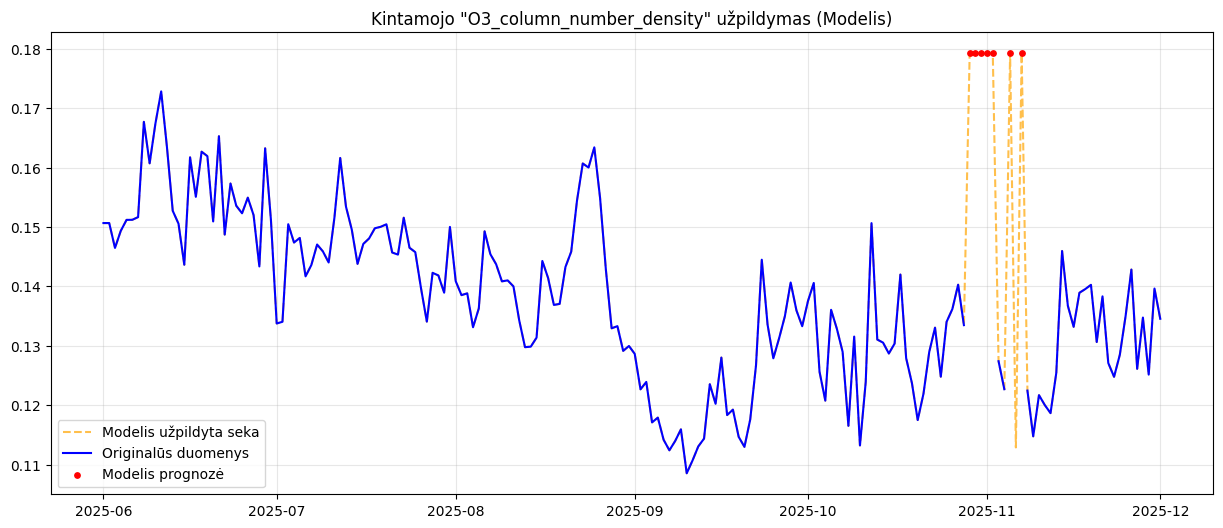

In [45]:
plot_imputation_results(
    data_orig=cut_combined_data, 
    data_filled=sarima_data, 
    variable='O3_column_number_density',
    start_date='2025-06-01',
    end_date='2025-12-01'
)

In [47]:
def simple_impute(df, target_col, window=30):
    series = df[target_col].copy()
    
    series = series.interpolate(method='linear')
    
    rolling_mean = series.rolling(window=window, min_periods=1, center=True).mean()
    series = series.fillna(rolling_mean)
    
    seasonal_mean = series.groupby(series.index.dayofweek).transform('mean')
    series = series.fillna(seasonal_mean)
    
    series = series.fillna(method='bfill').fillna(method='ffill')
    
    return series

In [48]:
simple_impute_data = cut_combined_data.copy()

cols_to_fix = [col for col in simple_impute_data.columns if simple_impute_data[col].isna().any()]

for col in cols_to_fix:
    simple_impute_data[col] = simple_impute(simple_impute_data, col)

print("Užpildymas baigtas!")

Užpildymas baigtas!


C:\Users\rugil\AppData\Local\Temp\ipykernel_23364\3325261838.py:12: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series = series.fillna(method='bfill').fillna(method='ffill')


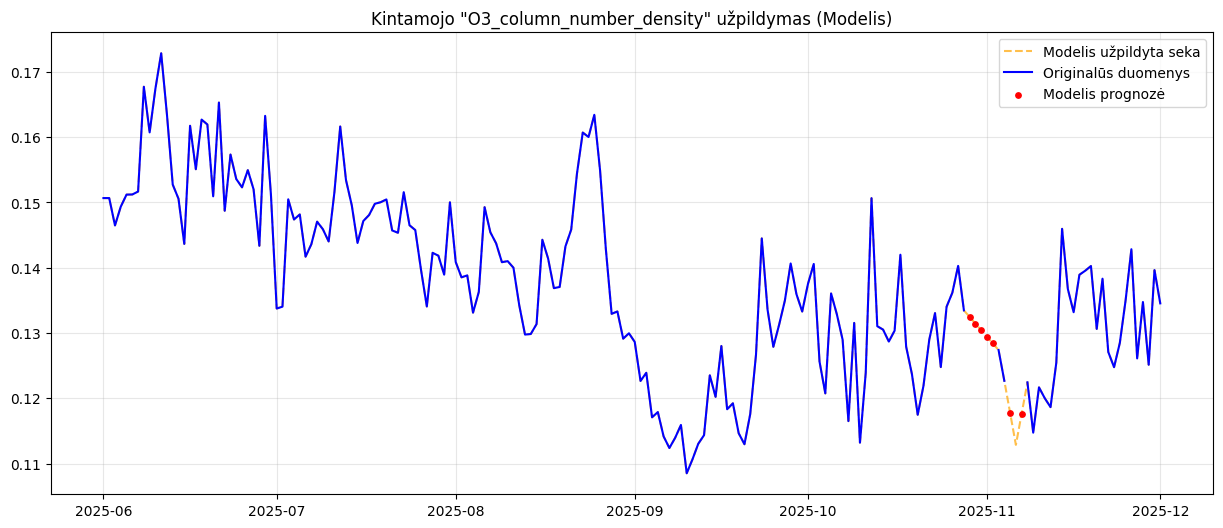

In [52]:
plot_imputation_results(
    data_orig=cut_combined_data, 
    data_filled=simple_impute_data, 
    variable='O3_column_number_density',
    start_date='2025-06-01',
    end_date='2025-12-01'
)

In [ ]:
# combined_data['day_of_year'] = combined_data.index.dayofyear

# combined_data['day_sin'] = np.sin(2 * np.pi * combined_data['day_of_year'] / 365.25)
# combined_data['day_cos'] = np.cos(2 * np.pi * combined_data['day_of_year'] / 365.25)

# combined_data['trend_step'] = np.arange(len(combined_data))

# MICE

In [64]:
# mice_cols = ['airTemperature', 'seaLevelPressure', 'relativeHumidity', 'missforest_precipitation', 'cloudCover_fixed',
#                 'feelsLikeTemperature_fixed', 'windSpeed_fixed',  'windGust_fixed', 'windDirection_fixed', 'absorbing_aerosol_index', 
#                 'cloud_fraction', 'NO2_column_number_density', 'stratospheric_NO2_column_number_density', 'NO2_slant_column_number_density', 
#                 'tropopause_pressure', 'O3_column_number_density', 'O3_effective_temperature', 'dust', 'sia', 'pm2p5', 'pans', 'nmvoc', 'nh3', 'pm10']

mice_cols = ['airTemperature', 'seaLevelPressure', 'relativeHumidity', 'missforest_precipitation', 'cloudCover_fixed', 'feelsLikeTemperature_fixed', 
             'windSpeed_fixed',  'windGust_fixed', 'windDirection_fixed', 'absorbing_aerosol_index', 'NO2_column_number_density', 
             'stratospheric_NO2_column_number_density', 'NO2_slant_column_number_density', 'tropopause_pressure', 'O3_column_number_density', 
             'O3_effective_temperature', 'H2O_column_number_density']

mice_subset = cut_combined_data[mice_cols].copy()

imputer = IterativeImputer(random_state=0)
imputed_data = imputer.fit_transform(mice_subset)

mice_imputed_data = pd.DataFrame(
    imputed_data,
    columns=mice_cols,
    index=mice_subset.index
)

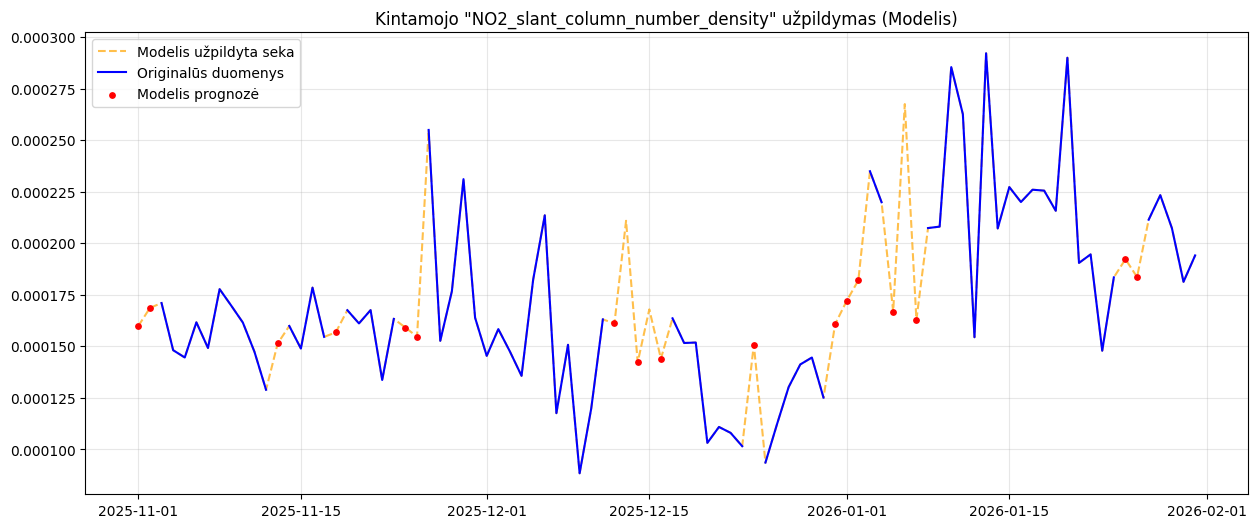

In [65]:
plot_imputation_results(
    data_orig=mice_subset, 
    data_filled=mice_imputed_data, 
    variable='NO2_slant_column_number_density',
    start_date='2025-11-01',
    end_date='2026-01-31'
)

# Long-term missing value imputation for time series data using deep neural networks

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

def prepare_data(df, target_col, feature_cols):
    train_data = df[df[target_col].notna()]
    missing_data = df[df[target_col].isna()]
    
    scaler_x = StandardScaler()
    scaler_y = StandardScaler()
    
    X_train = scaler_x.fit_transform(train_data[feature_cols])
    y_train = scaler_y.fit_transform(train_data[[target_col]])
    
    X_missing = scaler_x.transform(missing_data[feature_cols])
    
    return (torch.FloatTensor(X_train), 
            torch.FloatTensor(y_train), 
            torch.FloatTensor(X_missing), 
            scaler_x, scaler_y, missing_data.index)


class MLPImputer(nn.Module):
    def __init__(self, input_dim, hidden_layers=[256, 128, 64], dropout=0.1):
        super(MLPImputer, self).__init__()
        layers = []
        in_dim = input_dim
        
        for h_dim in hidden_layers:
            layers.append(nn.Linear(in_dim, h_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            in_dim = h_dim
            
        layers.append(nn.Linear(in_dim, 1))
        self.model = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.model(x)

def train_model(X_train, y_train, input_dim):
    model = MLPImputer(input_dim=input_dim)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    for epoch in range(1000):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
        
        if epoch % 10 == 0:
            print(f'Epoch {epoch}, Loss: {loss.item():.4f}')
    
    return model


In [64]:
feature_cols = ['airTemperature', 'seaLevelPressure', 'relativeHumidity','missforest_precipitation', 'cloudCover_fixed', 
                'feelsLikeTemperature_fixed', 'windSpeed_fixed', 'windGust_fixed', 'windDirection_fixed', 'dust',
                'sia', 'pm2p5', 'pans', 'nmvoc', 'nh3', 'pm10', "day_sin", 'day_cos', 'trend_step']
target_col = 'CO_column_number_density'

X_t, y_t, X_miss, sc_x, scaler, miss_idx = prepare_data(combined_data, target_col, feature_cols)
model = train_model(X_t, y_t, len(feature_cols))

Epoch 0, Loss: 1.0113
Epoch 10, Loss: 0.8267
Epoch 20, Loss: 0.7612
Epoch 30, Loss: 0.7159
Epoch 40, Loss: 0.6678
Epoch 50, Loss: 0.6219
Epoch 60, Loss: 0.5839
Epoch 70, Loss: 0.5326
Epoch 80, Loss: 0.4842
Epoch 90, Loss: 0.4617
Epoch 100, Loss: 0.4339
Epoch 110, Loss: 0.3910
Epoch 120, Loss: 0.3648
Epoch 130, Loss: 0.3440
Epoch 140, Loss: 0.3284
Epoch 150, Loss: 0.2866
Epoch 160, Loss: 0.2830
Epoch 170, Loss: 0.2508
Epoch 180, Loss: 0.2471
Epoch 190, Loss: 0.2325
Epoch 200, Loss: 0.2280
Epoch 210, Loss: 0.2079
Epoch 220, Loss: 0.2080
Epoch 230, Loss: 0.1973
Epoch 240, Loss: 0.1883
Epoch 250, Loss: 0.1757
Epoch 260, Loss: 0.1866
Epoch 270, Loss: 0.1815
Epoch 280, Loss: 0.1603
Epoch 290, Loss: 0.1576
Epoch 300, Loss: 0.1633
Epoch 310, Loss: 0.1464
Epoch 320, Loss: 0.1523
Epoch 330, Loss: 0.1471
Epoch 340, Loss: 0.1391
Epoch 350, Loss: 0.1317
Epoch 360, Loss: 0.1325
Epoch 370, Loss: 0.1292
Epoch 380, Loss: 0.1317
Epoch 390, Loss: 0.1260
Epoch 400, Loss: 0.1314
Epoch 410, Loss: 0.1275
Epo

In [65]:
filled_data = combined_data.copy()

model.eval()
with torch.no_grad():
    predictions = model(X_miss)
    final_values = scaler.inverse_transform(predictions.numpy())
    filled_data.loc[miss_idx, target_col] = final_values.flatten()

print("Užpildymas baigtas!")

Užpildymas baigtas!


In [66]:
missing_percent = filled_data.isnull().mean() * 100
print(missing_percent)

absorbing_aerosol_index                     1.056851
cloud_fraction                              7.361516
cloud_top_pressure                         11.188047
cloud_top_height                           11.224490
cloud_base_pressure                        11.188047
cloud_base_height                          11.224490
cloud_optical_depth                        11.224490
NO2_column_number_density                   6.268222
tropospheric_NO2_column_number_density     43.075802
stratospheric_NO2_column_number_density     6.268222
NO2_slant_column_number_density             6.268222
tropopause_pressure                         6.268222
O3_column_number_density                    4.336735
O3_effective_temperature                    4.336735
CO_column_number_density                    0.000000
H2O_column_number_density                  12.026239
airTemperature                              0.000000
seaLevelPressure                            0.000000
relativeHumidity                            0.

In [36]:
def plot_mlp_imputation(data_orig, data_filled, variable, miss_idx, start_date=None, end_date=None):
    if start_date:
        start_date = pd.to_datetime(start_date)
    if end_date:
        end_date = pd.to_datetime(end_date)

    if start_date and end_date:
        orig_plot = data_orig.loc[start_date:end_date]
        filled_plot = data_filled.loc[start_date:end_date]
        current_miss_idx = [i for i in miss_idx if start_date <= i <= end_date]
    else:
        orig_plot = data_orig
        filled_plot = data_filled
        current_miss_idx = miss_idx

    plt.figure(figsize=(15, 7))

    plt.plot(filled_plot.index, filled_plot[variable], 
             label='MLP Užpildyta seka', color='orange', linestyle='--')

    plt.plot(orig_plot.index, orig_plot[variable], 
             label='Originalūs duomenys', color='blue', linewidth=1)
    
    if len(current_miss_idx) > 0:
        plt.scatter(current_miss_idx, filled_plot.loc[current_miss_idx, variable], 
                    color='red', s=10, label='MLP Prognozė (spraga)', zorder=5)

    plt.title(f'Kintamojo {variable} užpildymas')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

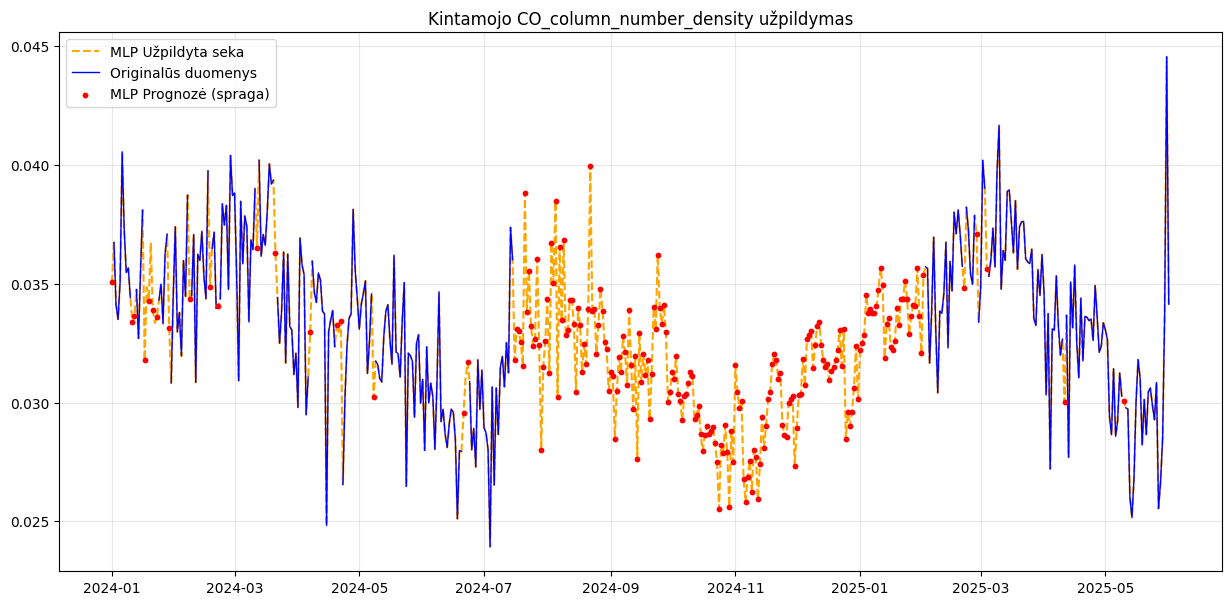

In [58]:
plot_mlp_imputation(combined_data, filled_data, 'CO_column_number_density', miss_idx, start_date='2024-01-01',
              end_date='2025-06-01')

## Testavimas

In [68]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def perform_validation(df, target_col, feature_cols, start_test, end_test):
    val_df = df.copy()
    test_idx = val_df.loc[start_test:end_test].index
    
    true_values = val_df.loc[test_idx, target_col].copy()
    test_idx = test_idx[true_values.notna()]
    true_values = true_values.dropna()
    
    val_df.loc[test_idx, target_col] = np.nan
    
    X_t, y_t, X_miss, sc_x, sc_y, m_idx = prepare_data(val_df, target_col, feature_cols)
    
    model = train_model(X_t, y_t, len(feature_cols))
    
    model.eval()
    with torch.no_grad():
        X_test_scaled = sc_x.transform(val_df.loc[test_idx, feature_cols])
        X_test_tensor = torch.FloatTensor(X_test_scaled)

        preds = model(X_test_tensor)
        predicted_values = sc_y.inverse_transform(preds.numpy()).flatten()
    
    mse = mean_squared_error(true_values, predicted_values)
    rmse = np.sqrt(mse)
    r2 = r2_score(true_values, predicted_values)
    
    print(f"\n--- TESTAVIMO REZULTATAI ({start_test} iki {end_test}) ---")
    print(f"Lyginama taškų: {len(true_values)}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²:   {r2:.4f}")
    
    return true_values, predicted_values, test_idx

In [75]:
true_v, pred_v, m_idx = perform_validation(combined_data, target_col, feature_cols, 
                                            '2024-01-01', '2024-03-01')

Epoch 0, Loss: 1.0119
Epoch 10, Loss: 0.8226
Epoch 20, Loss: 0.7703
Epoch 30, Loss: 0.7104
Epoch 40, Loss: 0.6636
Epoch 50, Loss: 0.6348
Epoch 60, Loss: 0.5868
Epoch 70, Loss: 0.5464
Epoch 80, Loss: 0.5120
Epoch 90, Loss: 0.4781
Epoch 100, Loss: 0.4415
Epoch 110, Loss: 0.4122
Epoch 120, Loss: 0.3926
Epoch 130, Loss: 0.3464
Epoch 140, Loss: 0.3205
Epoch 150, Loss: 0.2961
Epoch 160, Loss: 0.2926
Epoch 170, Loss: 0.2605
Epoch 180, Loss: 0.2594
Epoch 190, Loss: 0.2346
Epoch 200, Loss: 0.2341
Epoch 210, Loss: 0.2074
Epoch 220, Loss: 0.2008
Epoch 230, Loss: 0.1910
Epoch 240, Loss: 0.1877
Epoch 250, Loss: 0.1905
Epoch 260, Loss: 0.1768
Epoch 270, Loss: 0.1724
Epoch 280, Loss: 0.1756
Epoch 290, Loss: 0.1607
Epoch 300, Loss: 0.1519
Epoch 310, Loss: 0.1476
Epoch 320, Loss: 0.1508
Epoch 330, Loss: 0.1447
Epoch 340, Loss: 0.1469
Epoch 350, Loss: 0.1367
Epoch 360, Loss: 0.1399
Epoch 370, Loss: 0.1284
Epoch 380, Loss: 0.1336
Epoch 390, Loss: 0.1334
Epoch 400, Loss: 0.1225
Epoch 410, Loss: 0.1254
Epo

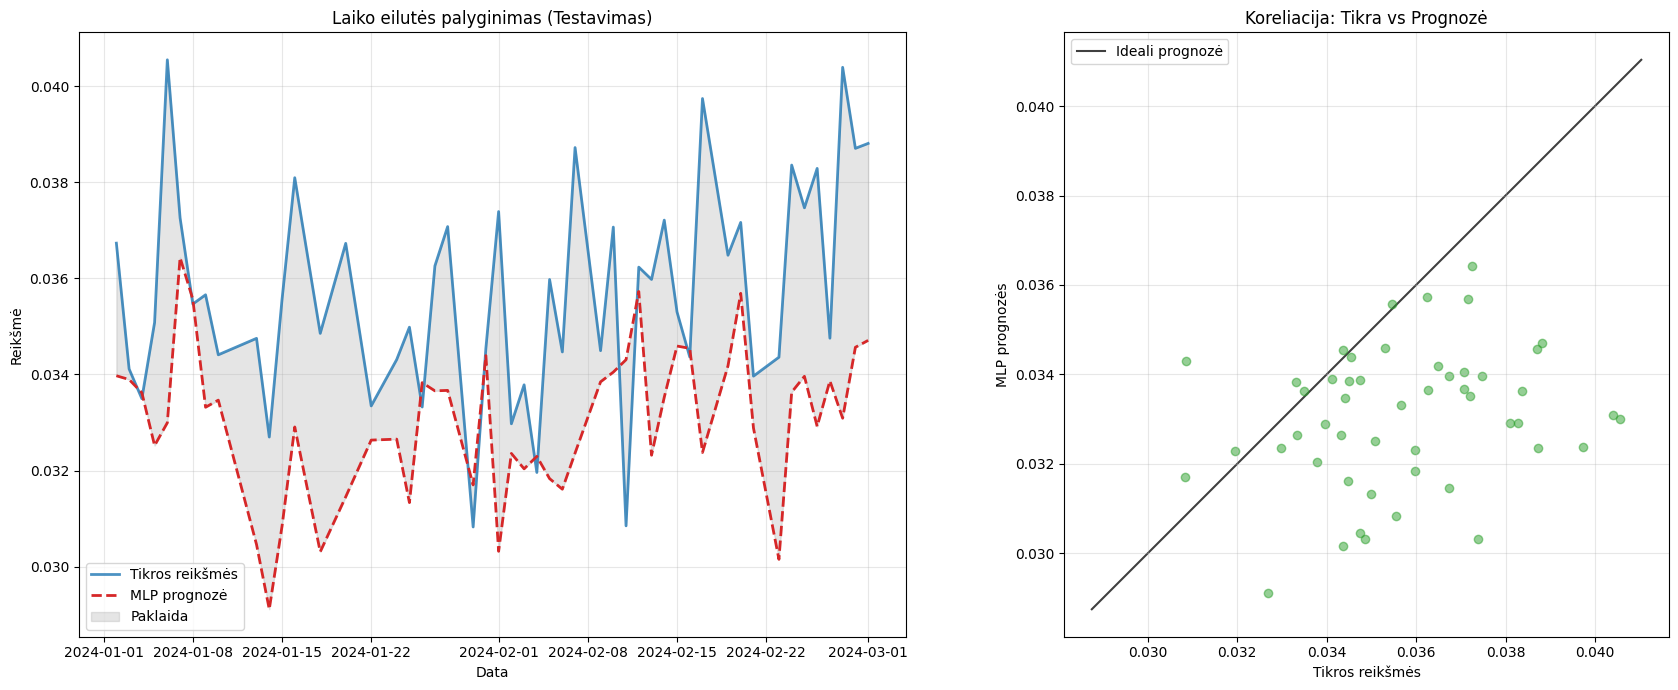

In [ ]:
def plot_validation_results(true_v, pred_v, index):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

    ax1.plot(index, true_v, label='Tikros reikšmės', color='#1f77b4', linewidth=2, alpha=0.8)
    ax1.plot(index, pred_v, label='MLP prognozė', color='#d62728', linestyle='--', linewidth=2)
    ax1.fill_between(index, true_v, pred_v, color='gray', alpha=0.2, label='Paklaida')
    
    ax1.set_title('Laiko eilutės palyginimas (Testavimas)')
    ax1.set_xlabel('Data')
    ax1.set_ylabel('Reikšmė')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.scatter(true_v, pred_v, alpha=0.5, color='#2ca02c')
    
    lims = [
        np.min([ax2.get_xlim(), ax2.get_ylim()]),
        np.max([ax2.get_xlim(), ax2.get_ylim()]), 
    ]
    ax2.plot(lims, lims, 'k-', alpha=0.75, zorder=0, label='Ideali prognozė')
    
    ax2.set_title('Koreliacija: Tikra vs Prognozė')
    ax2.set_xlabel('Tikros reikšmės')
    ax2.set_ylabel('MLP prognozės')
    ax2.set_aspect('equal')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_validation_results(true_v, pred_v, m_idx)